In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thu thập & Tiền Xử Lý Dữ Liệu

In [51]:
data=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(data.shape)
data.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [52]:
df=data.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [53]:
for col in df.columns:
    print(f" Các giá trị của cột {col}: {df[col].unique()}")


 Các giá trị của cột customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
 Các giá trị của cột gender: ['Female' 'Male']
 Các giá trị của cột SeniorCitizen: [0 1]
 Các giá trị của cột Partner: ['Yes' 'No']
 Các giá trị của cột Dependents: ['No' 'Yes']
 Các giá trị của cột tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
 Các giá trị của cột PhoneService: ['No' 'Yes']
 Các giá trị của cột MultipleLines: ['No phone service' 'No' 'Yes']
 Các giá trị của cột InternetService: ['DSL' 'Fiber optic' 'No']
 Các giá trị của cột OnlineSecurity: ['No' 'Yes' 'No internet service']
 Các giá trị của cột OnlineBackup: ['Yes' 'No' 'No internet service']
 Các giá trị của cột DeviceProtection: ['No' 'Yes' 'No internet service']
 Các giá trị của cột TechSupport: ['No' 'Yes' 'No inte

## Xử lý dữ liệu

### Trong dataset, cột TotalCharges đáng ra phải là số (float) vì nó là tổng tiền khách hàng đã trả. Nhưng ở đây lại đang là object nên cần phải xử lý


In [54]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [55]:
df['TotalCharges'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7032 non-null   float64
dtypes: float64(1)
memory usage: 55.1 KB


In [56]:
# Hiển thị các giá trị bị thiếu trong cột 'TotalCharges'
missing_values = df['TotalCharges'].isnull()
print(missing_values.sum())

11


###  Có 11 trường dữ liệu trong cột  TotalCharges chứa NaN vậy để kiểm tra vấn đề cần xem xét 3 cột dữ liệu chính là tenure, MonthlyCharges, Churn giúp biết được khách hàng đã sử dụng dịch vụ trong bao lâu, mỗi tháng chi phí là bao nhiêu và khách hàng đã rời bỏ dịch vụ hay chưa

In [57]:
df[df['TotalCharges'].isnull()][['tenure','MonthlyCharges','Churn']]

,tenure,MonthlyCharges,Churn
488,0,52.55,No
753,0,20.25,No
936,0,80.85,No
1082,0,25.75,No
1340,0,56.05,No
3331,0,19.85,No
3826,0,25.35,No
4380,0,20.00,No
5218,0,19.70,No
6670,0,73.35,No


### tenure = 0 nghĩa là khách hàng vừa mới đăng kí và chưa sử dụng hết 1 tháng dẫn tới chi phí chưa phát sinh vậy có thể Drop NA hoặc thay thế bằng 0

In [58]:
df['TotalCharges'].fillna(0, inplace=True)

C:\Users\vhgam\AppData\Local\Temp\ipykernel_9788\171940771.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [59]:
missing_values = df['TotalCharges'].isnull()
print(missing_values.sum())

0


### Kiểm tra dữ liệu trùng lặp

In [60]:
# kiểm tra dữ liệu trùng lặp 
duplicate_rows = df[df.duplicated()]
print(f"Số lượng dòng trùng lặp: {duplicate_rows.shape[0]}")

Số lượng dòng trùng lặp: 0


### kiểm tra dữ liệu ngoại lai

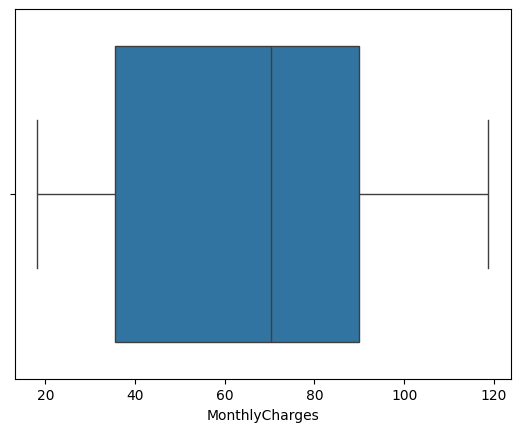

In [13]:
sns.boxplot(x=df['MonthlyCharges'])
plt.show()

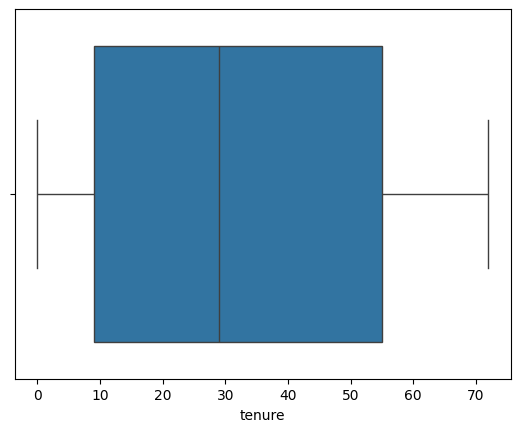

In [14]:
sns.boxplot(x=df['tenure'])
plt.show()

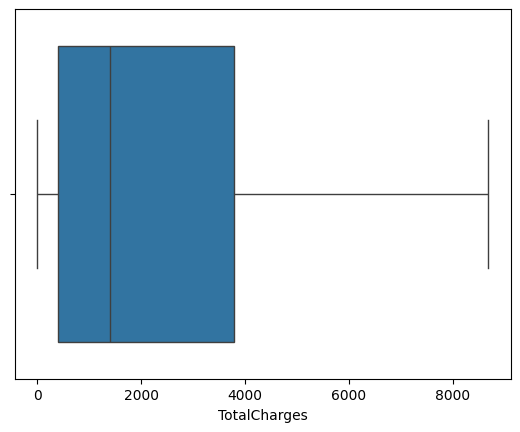

In [15]:
sns.boxplot(x=df['TotalCharges'])
plt.show()

#### Không có giá trị nào bất thường

## Chuẩn hóa dữ liệu

In [61]:
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']

for col in service_cols:
    df[col] = df[col].replace({'No internet service':'No'})


In [62]:
df['MultipleLines'] = df['MultipleLines'].replace({'No phone service':'No'})


In [63]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0:'No', 1:'Yes'})

In [64]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
# lưu file đã xử lý
df.to_csv("cleaned_telco.csv", index=False)

In [102]:
df=pd.read_csv("cleaned_telco.csv")
print(df.shape) 
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Phân Tích Dữ Liệu Khám Phá (EDA)

## Churn - Khách hàng có rời bỏ dịch vụ hay không ?

C:\Users\vhgam\AppData\Local\Temp\ipykernel_9788\3032614736.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette=['#4CAF50', '#F44336'])


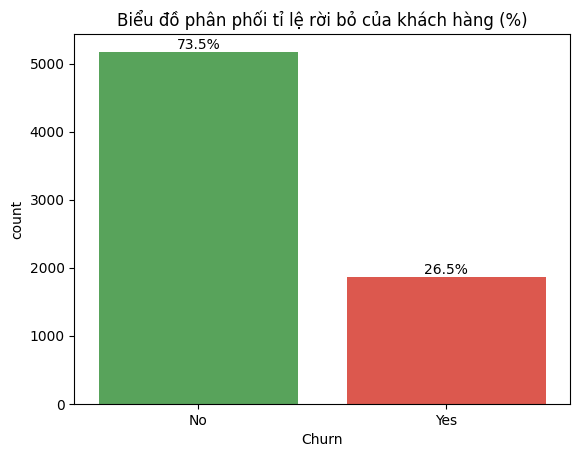

In [67]:
ax = sns.countplot(x='Churn', data=df, palette=['#4CAF50', '#F44336'])

total = len(df)

for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Biểu đồ phân phối tỉ lệ rời bỏ của khách hàng (%)')
plt.show()

## Gender

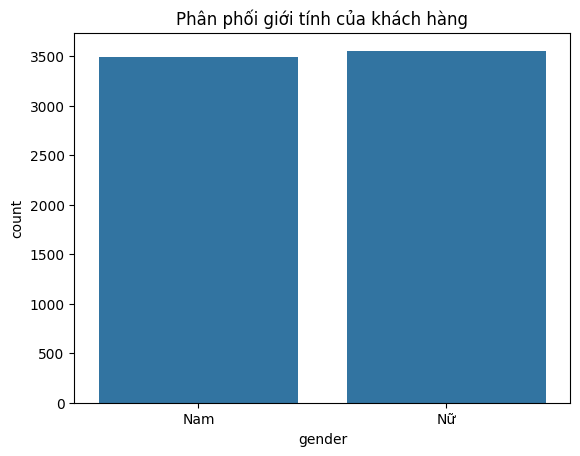

In [68]:
sns.countplot(x='gender', data=df)
plt.title('Phân phối giới tính của khách hàng')
plt.xticks([0, 1], ['Nam', 'Nữ'])
plt.show()

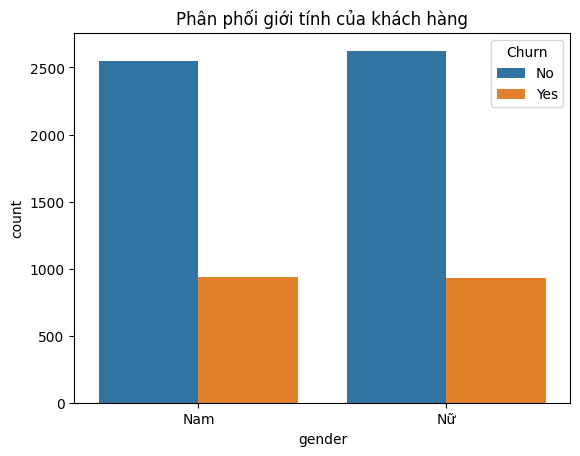

In [69]:
sns.countplot(x='gender', hue='Churn', data=df)
plt.title('Phân phối giới tính của khách hàng')
plt.xticks([0, 1], ['Nam', 'Nữ'])
plt.show()

## SeniorCitizen

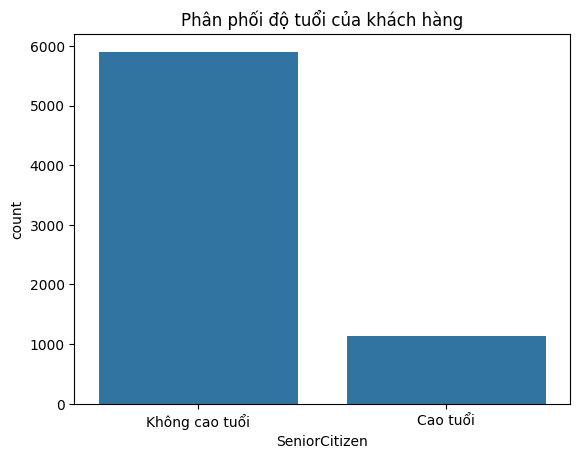

In [70]:
sns.countplot(x='SeniorCitizen', data=df)
plt.title('Phân phối độ tuổi của khách hàng')
plt.xticks([0, 1], ['Không cao tuổi', 'Cao tuổi'])
plt.show()

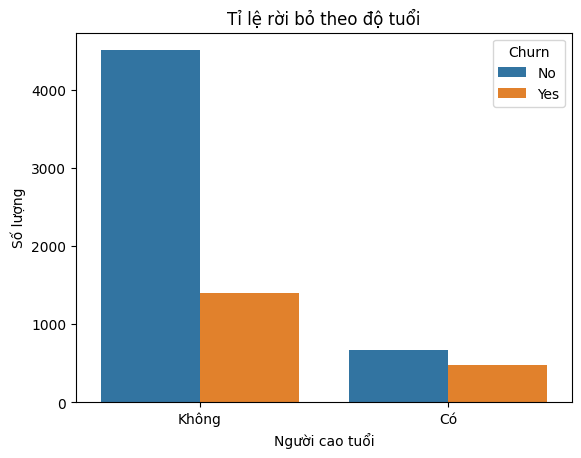

In [71]:
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title('Tỉ lệ rời bỏ theo độ tuổi')
plt.xlabel('Người cao tuổi')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

## Partner

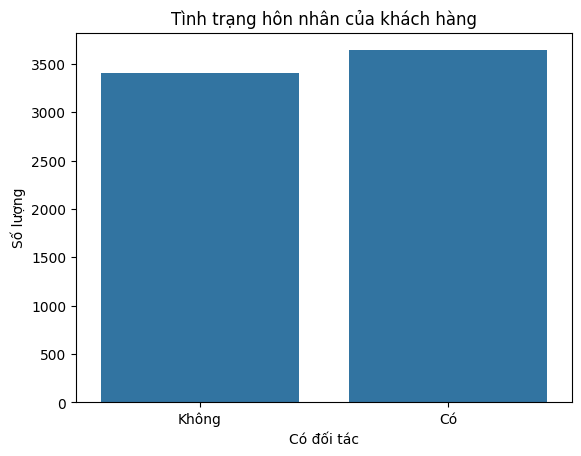

In [72]:
sns.countplot(x='Partner', data=df)
plt.title('Tình trạng hôn nhân của khách hàng')
plt.xlabel('Có đối tác')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

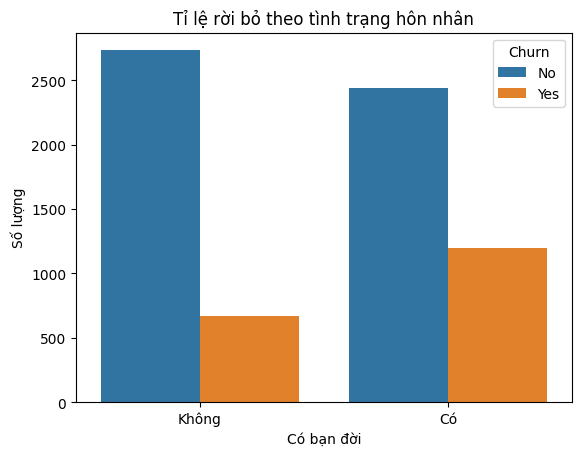

In [73]:
sns.countplot(x='Partner', hue='Churn', data=df)
plt.title('Tỉ lệ rời bỏ theo tình trạng hôn nhân')
plt.xlabel('Có bạn đời')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

## Dependents - Người phụ thuộc

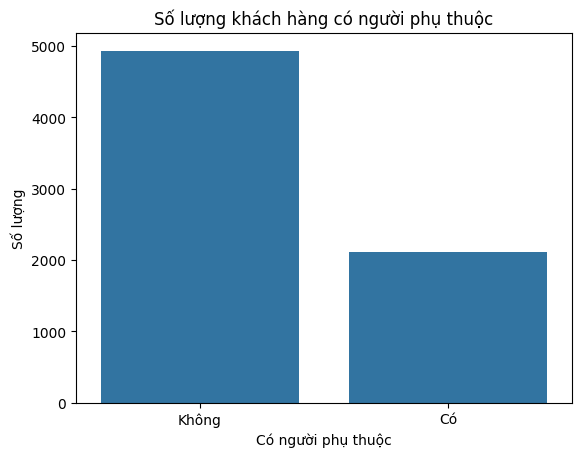

In [74]:
sns.countplot(x='Dependents', data=df)
plt.title('Số lượng khách hàng có người phụ thuộc')
plt.xlabel('Có người phụ thuộc')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

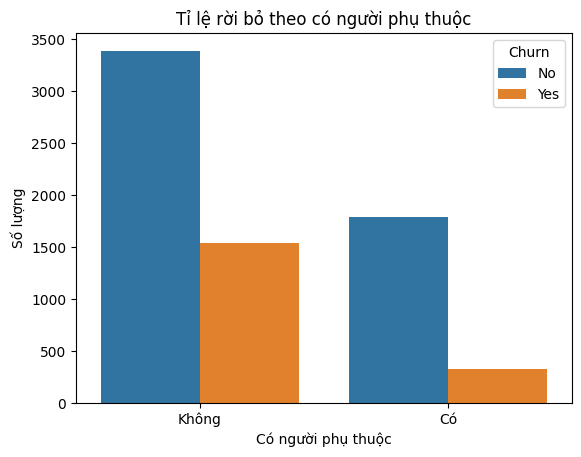

In [75]:
sns.countplot(x='Dependents', hue='Churn', data=df)
plt.title('Tỉ lệ rời bỏ theo có người phụ thuộc')
plt.xlabel('Có người phụ thuộc')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

## PhoneService - Khách hàng có sử dụng dịch vụ điện thoại hay không

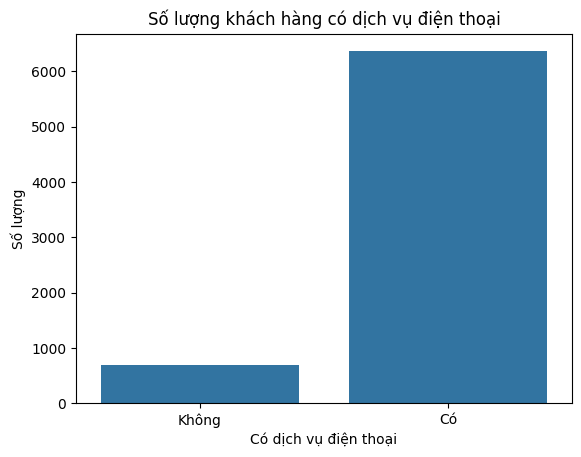

In [76]:
sns.countplot(x='PhoneService', data=df)
plt.title('Số lượng khách hàng có dịch vụ điện thoại')
plt.xlabel('Có dịch vụ điện thoại')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

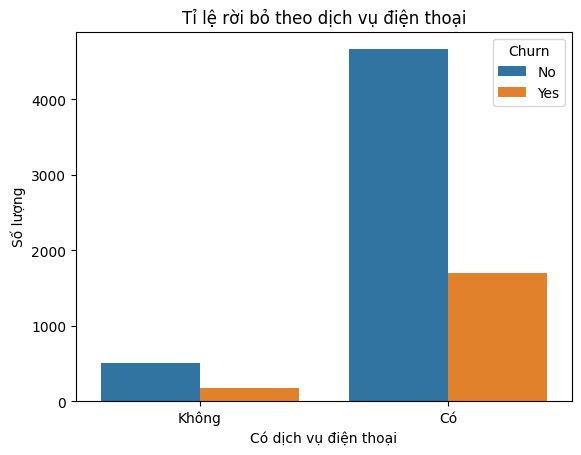

In [77]:
sns.countplot(x='PhoneService', hue='Churn', data=df)
plt.title('Tỉ lệ rời bỏ theo dịch vụ điện thoại')
plt.xlabel('Có dịch vụ điện thoại')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

## MultipleLines

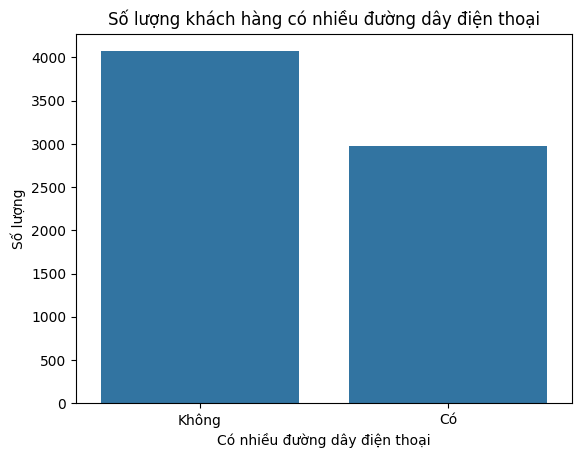

In [78]:
sns.countplot(x='MultipleLines', data=df)
plt.title('Số lượng khách hàng có nhiều đường dây điện thoại')
plt.xlabel('Có nhiều đường dây điện thoại')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

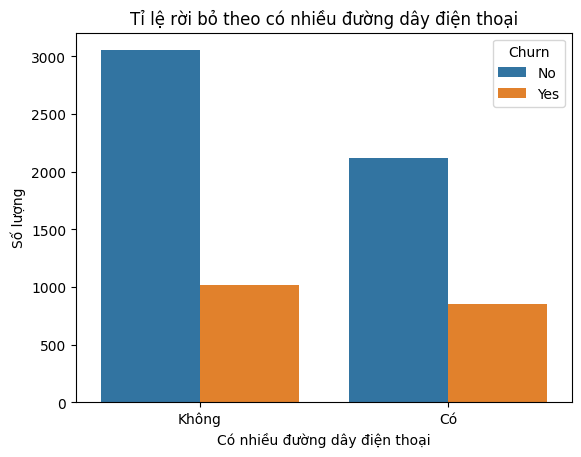

In [79]:
sns.countplot(x='MultipleLines', hue='Churn', data=df)
plt.title('Tỉ lệ rời bỏ theo có nhiều đường dây điện thoại')
plt.xlabel('Có nhiều đường dây điện thoại')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

## Contract

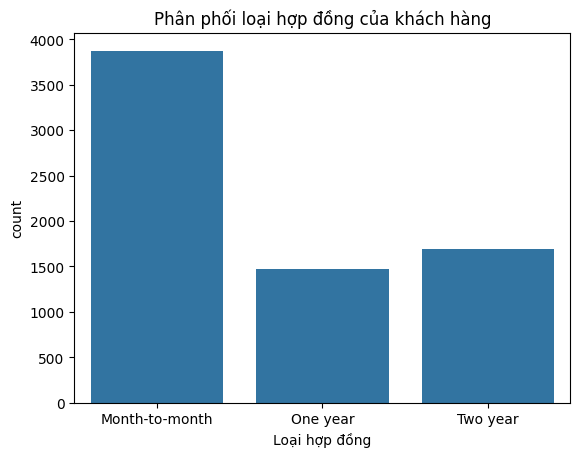

In [80]:
sns.countplot(x='Contract', data=df)
plt.title('Phân phối loại hợp đồng của khách hàng')
plt.xlabel('Loại hợp đồng')
plt.xticks([0, 1, 2], ['Month-to-month', 'One year', 'Two year'])
plt.show()

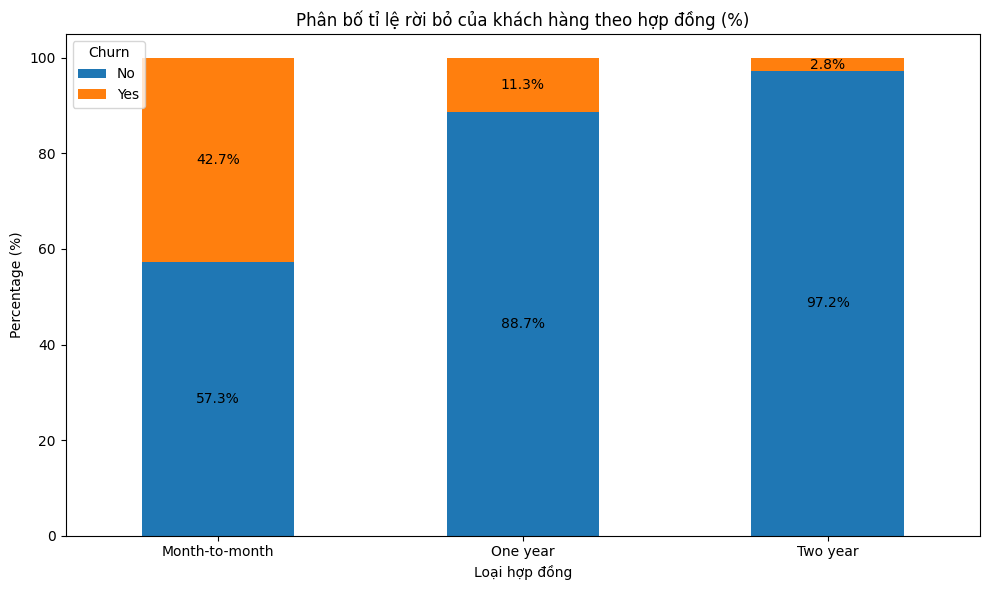

In [81]:
#Phân bố tỉ lệ rời bỏ của khách hàng theo hợp đồng (%)
churn_contract = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100
ax = churn_contract.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
)

# Hiển thị % trên cột
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.title('Phân bố tỉ lệ rời bỏ của khách hàng theo hợp đồng (%)')
plt.ylabel('Percentage (%)')
plt.xlabel('Loại hợp đồng')
plt.legend(title='Churn')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## PaymentMethod

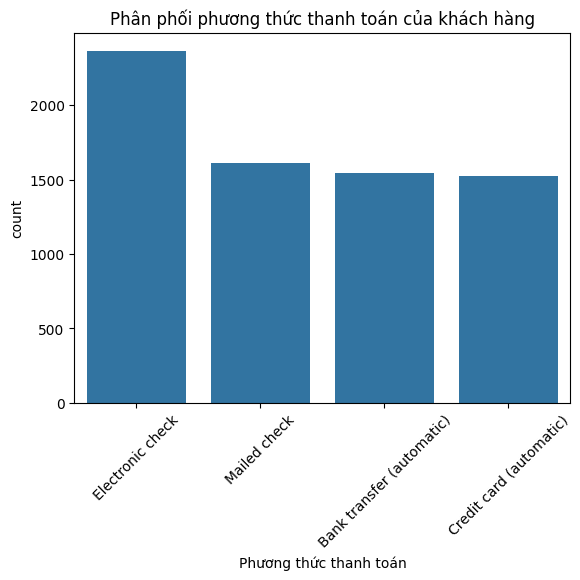

In [84]:
sns.countplot(x='PaymentMethod', data=df)
plt.title('Phân phối phương thức thanh toán của khách hàng')
plt.xlabel('Phương thức thanh toán')
plt.xticks(rotation=45)
plt.show()

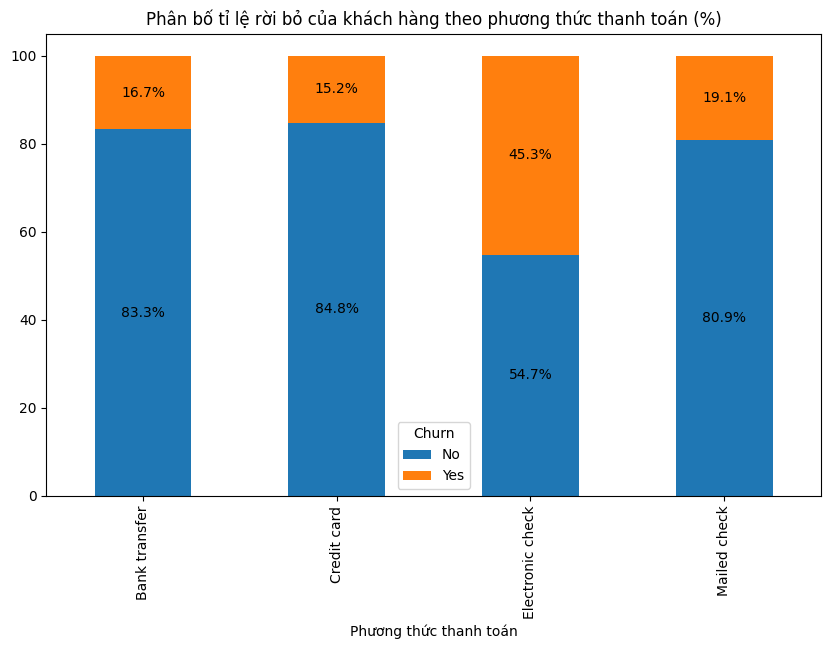

In [85]:

df['PaymentMethod_group'] = df['PaymentMethod'].map({
    'Electronic check':'Electronic check',
    'Mailed check':'Mailed check',
    'Bank transfer (automatic)':'Bank transfer',
    'Credit card (automatic)':'Credit card'
})
payment_churn_pct = pd.crosstab(
    df['PaymentMethod_group'],
    df['Churn'],
    normalize='index'
) * 100
ax = payment_churn_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),


)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')
plt.title('Phân bố tỉ lệ rời bỏ của khách hàng theo phương thức thanh toán (%)')
plt.xlabel('Phương thức thanh toán')
plt.legend(title='Churn')
plt.show()

## TechSupport

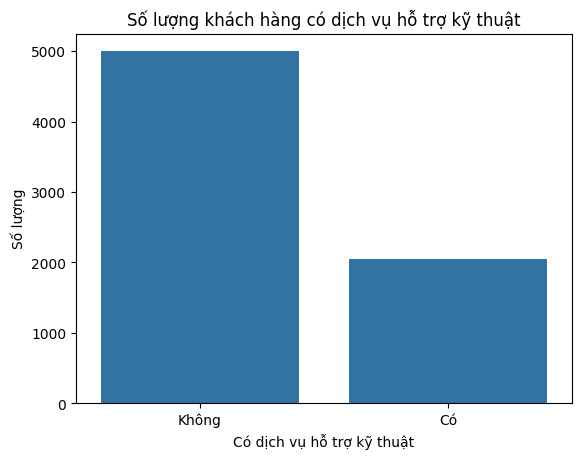

In [99]:
sns.countplot(x='TechSupport', data=df)
plt.title('Số lượng khách hàng có dịch vụ hỗ trợ kỹ thuật')
plt.xlabel('Có dịch vụ hỗ trợ kỹ thuật')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

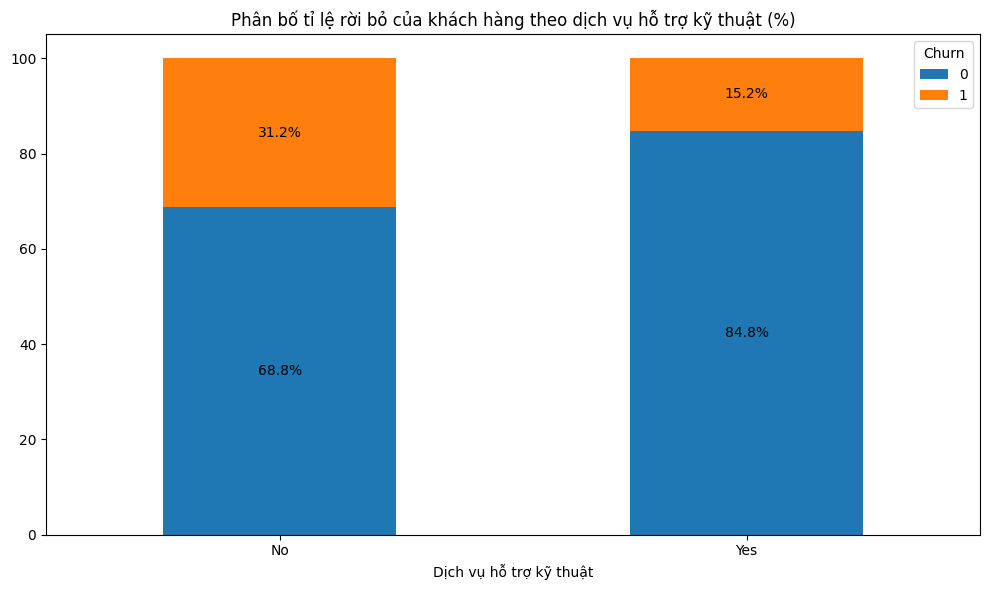

In [103]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
df['TechSupport'] = df['TechSupport'].map({'No': 0, 'Yes': 1})
TechSupport_churn_pct = pd.crosstab(
    df['TechSupport'],
    df['Churn'],
    normalize='index'   
)* 100
ax = TechSupport_churn_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')
plt.title('Phân bố tỉ lệ rời bỏ của khách hàng theo dịch vụ hỗ trợ kỹ thuật (%)')
plt.xlabel('Dịch vụ hỗ trợ kỹ thuật')
plt.legend(title='Churn')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.tight_layout()
plt.show()

## tenure

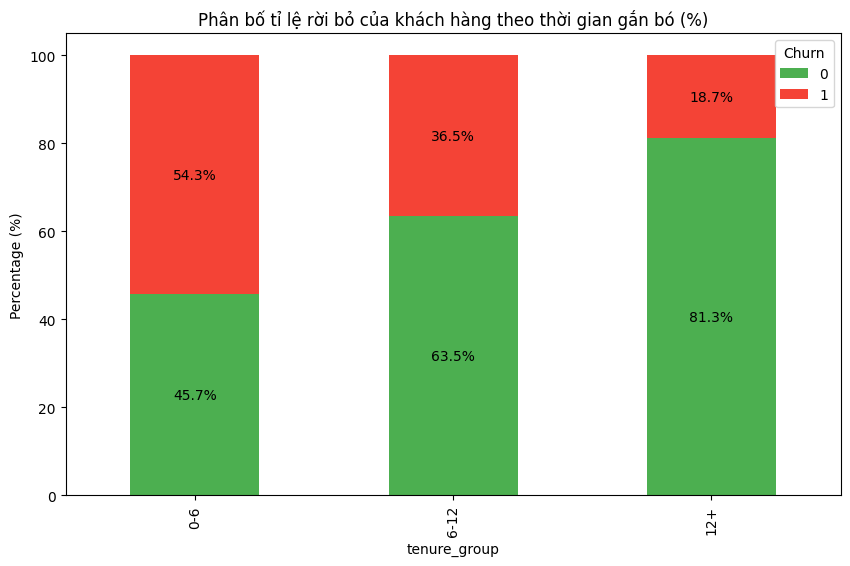

In [88]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, df['tenure'].max()],
    labels=['0-6', '6-12', '12+'],
    right=False
)
# Tính % theo từng bin
churn_pct = pd.crosstab(
    df['tenure_group'],
    df['Churn'],
    normalize='index'
) * 100

# Vẽ stacked bar chart
ax = churn_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#4CAF50', '#F44336']
)

# Hiển thị % trên từng phần
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.ylabel('Percentage (%)')
plt.title('Phân bố tỉ lệ rời bỏ của khách hàng theo thời gian gắn bó (%)')
plt.legend(title='Churn')
plt.show()

## InternetService

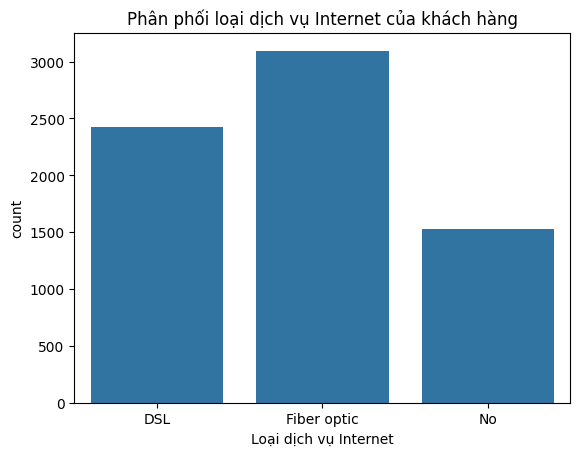

In [89]:
sns.countplot(x='InternetService', data=df)
plt.title('Phân phối loại dịch vụ Internet của khách hàng')
plt.xlabel('Loại dịch vụ Internet')
plt.show()

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   int64  
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


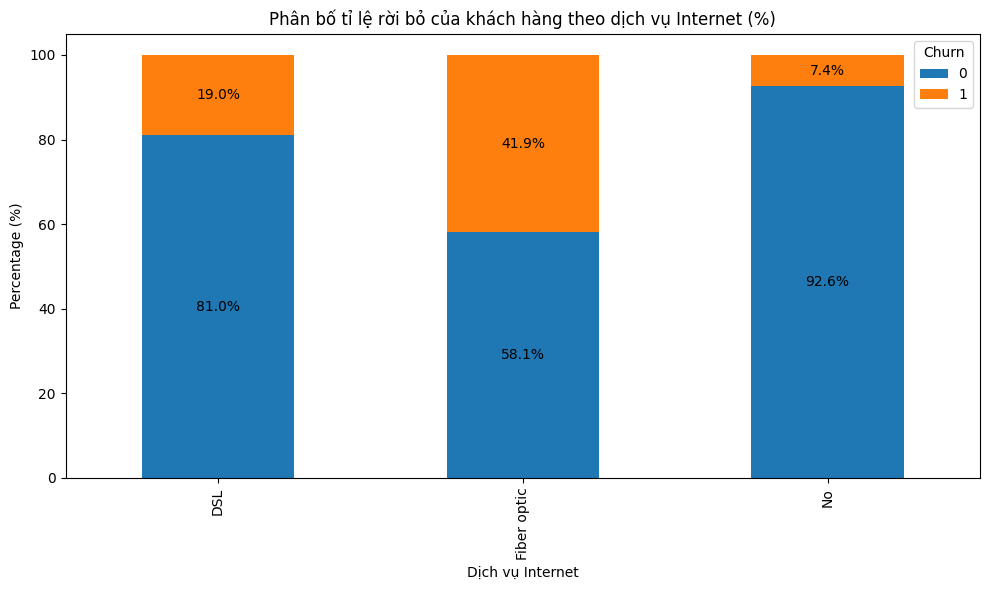

In [119]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
InternetService_churn_pct = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'   
)* 100
ax = InternetService_churn_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')
plt.title('Phân bố tỉ lệ rời bỏ của khách hàng theo dịch vụ Internet (%)')
plt.xlabel('Dịch vụ Internet')
plt.ylabel('Percentage (%)')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()



## OnlineSecurity

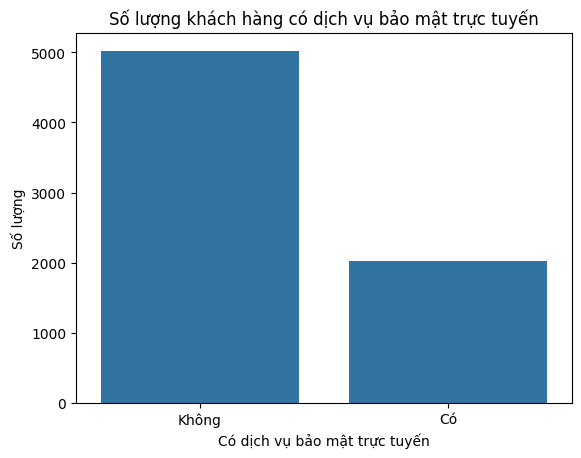

In [120]:
sns.countplot(x='OnlineSecurity', data=df)
plt.title('Số lượng khách hàng có dịch vụ bảo mật trực tuyến')
plt.xlabel('Có dịch vụ bảo mật trực tuyến')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

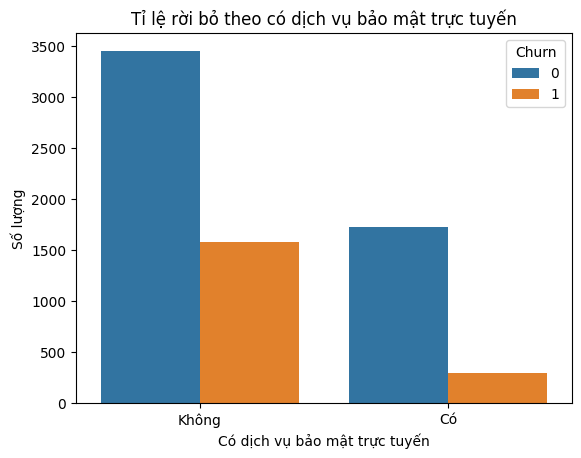

In [121]:
sns.countplot(x='OnlineSecurity', hue='Churn', data=df)
plt.title('Tỉ lệ rời bỏ theo có dịch vụ bảo mật trực tuyến')
plt.xlabel('Có dịch vụ bảo mật trực tuyến')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

## OnlineBackup

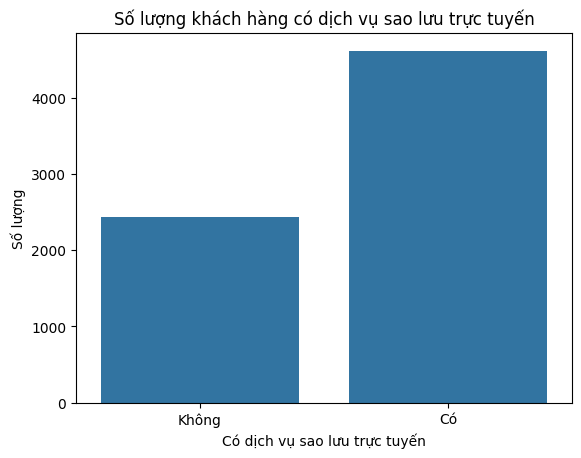

In [122]:
sns.countplot(x='OnlineBackup', data=df)
plt.title('Số lượng khách hàng có dịch vụ sao lưu trực tuyến')
plt.xlabel('Có dịch vụ sao lưu trực tuyến')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

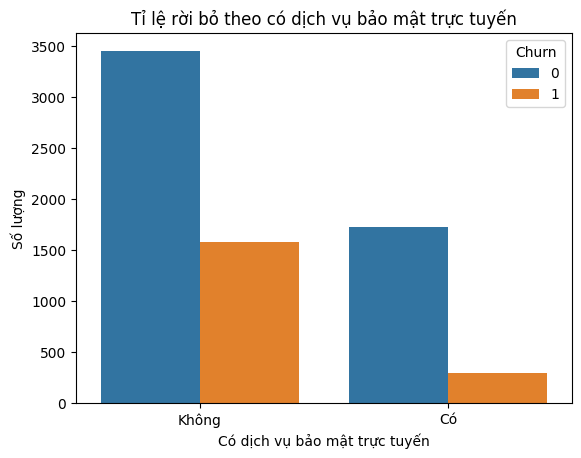

In [123]:
sns.countplot(x='OnlineSecurity', hue='Churn', data=df)
plt.title('Tỉ lệ rời bỏ theo có dịch vụ bảo mật trực tuyến')
plt.xlabel('Có dịch vụ bảo mật trực tuyến')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

## DeviceProtection

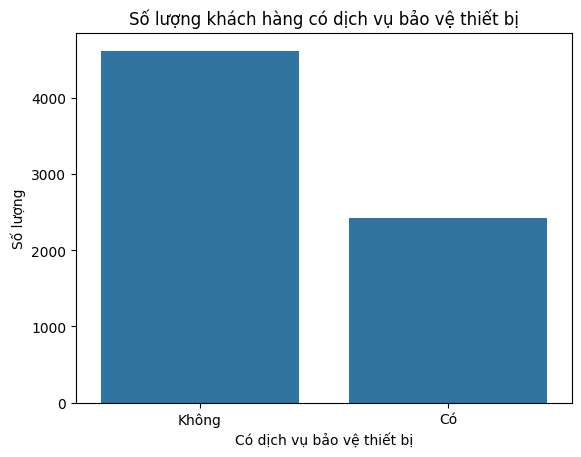

In [124]:
sns.countplot(x='DeviceProtection', data=df)
plt.title('Số lượng khách hàng có dịch vụ bảo vệ thiết bị')
plt.xlabel('Có dịch vụ bảo vệ thiết bị')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

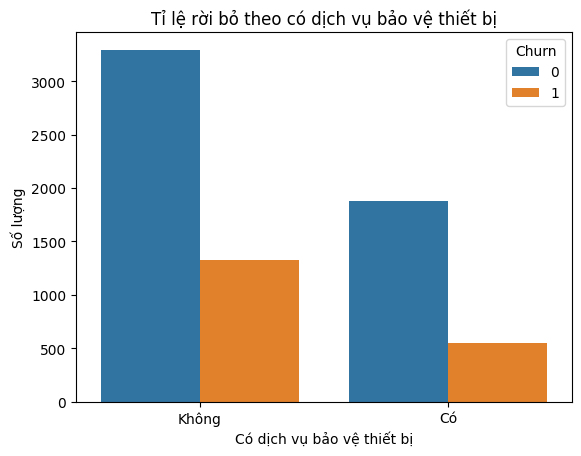

In [125]:
sns.countplot(x='DeviceProtection', hue='Churn', data=df)
plt.title('Tỉ lệ rời bỏ theo có dịch vụ bảo vệ thiết bị')
plt.xlabel('Có dịch vụ bảo vệ thiết bị')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

## StreamingTV

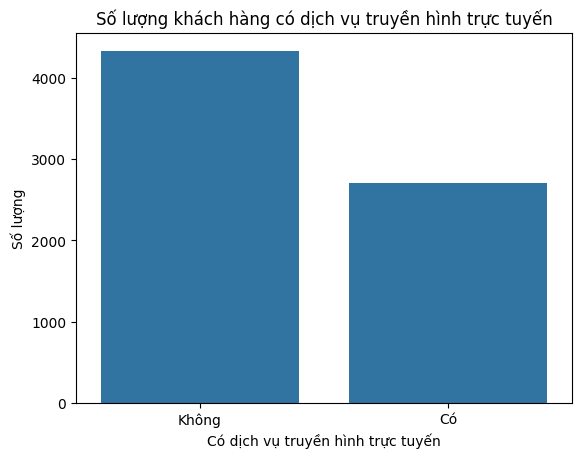

In [126]:
sns.countplot(x='StreamingTV', data=df)
plt.title('Số lượng khách hàng có dịch vụ truyền hình trực tuyến')
plt.xlabel('Có dịch vụ truyền hình trực tuyến')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

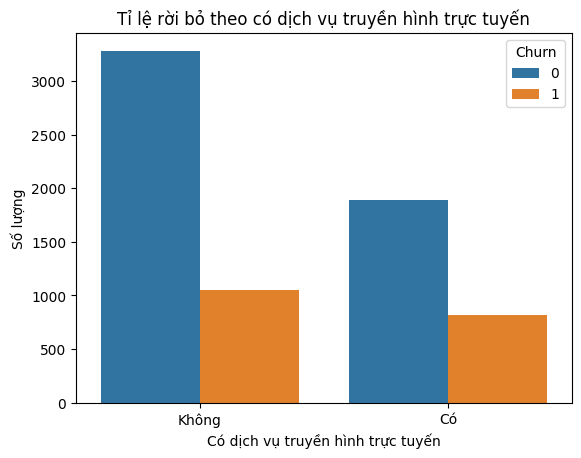

In [127]:
sns.countplot(x='StreamingTV', hue='Churn', data=df)
plt.title('Tỉ lệ rời bỏ theo có dịch vụ truyền hình trực tuyến')
plt.xlabel('Có dịch vụ truyền hình trực tuyến')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

## Streaming Movie

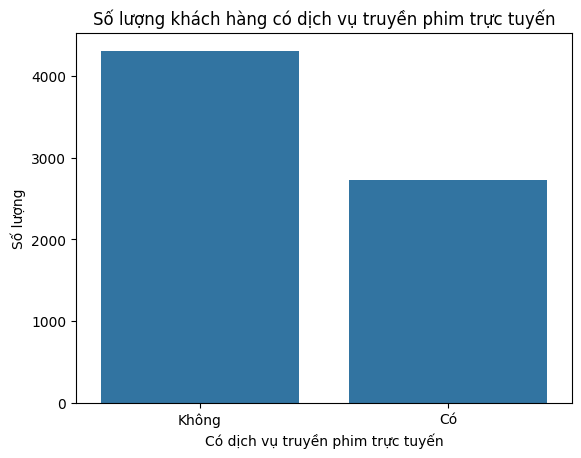

In [128]:
sns.countplot(x='StreamingMovies', data=df)
plt.title('Số lượng khách hàng có dịch vụ truyền phim trực tuyến')
plt.xlabel('Có dịch vụ truyền phim trực tuyến')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

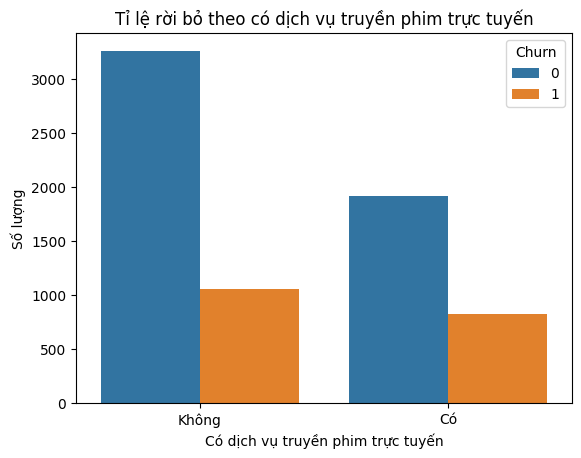

In [129]:
sns.countplot(x='StreamingMovies', hue='Churn', data=df)
plt.title('Tỉ lệ rời bỏ theo có dịch vụ truyền phim trực tuyến')
plt.xlabel('Có dịch vụ truyền phim trực tuyến')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

## PaperlessBilling

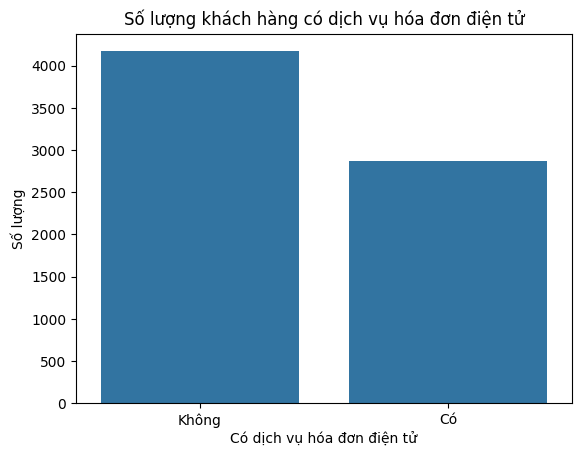

In [130]:
sns.countplot(x='PaperlessBilling', data=df)
plt.title('Số lượng khách hàng có dịch vụ hóa đơn điện tử')
plt.xlabel('Có dịch vụ hóa đơn điện tử')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

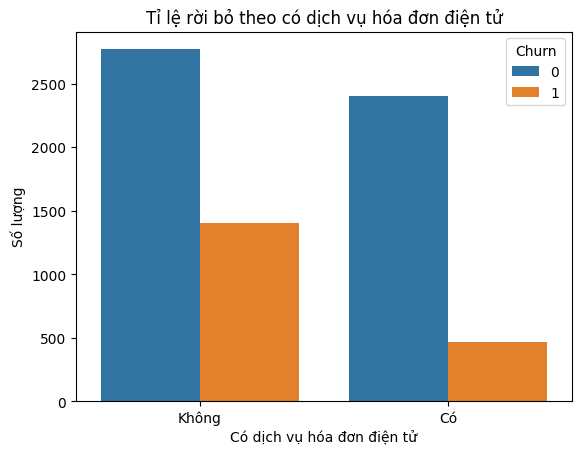

In [131]:
sns.countplot(x='PaperlessBilling', hue='Churn', data=df)
plt.title('Tỉ lệ rời bỏ theo có dịch vụ hóa đơn điện tử')
plt.xlabel('Có dịch vụ hóa đơn điện tử')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['Không', 'Có'])
plt.show()

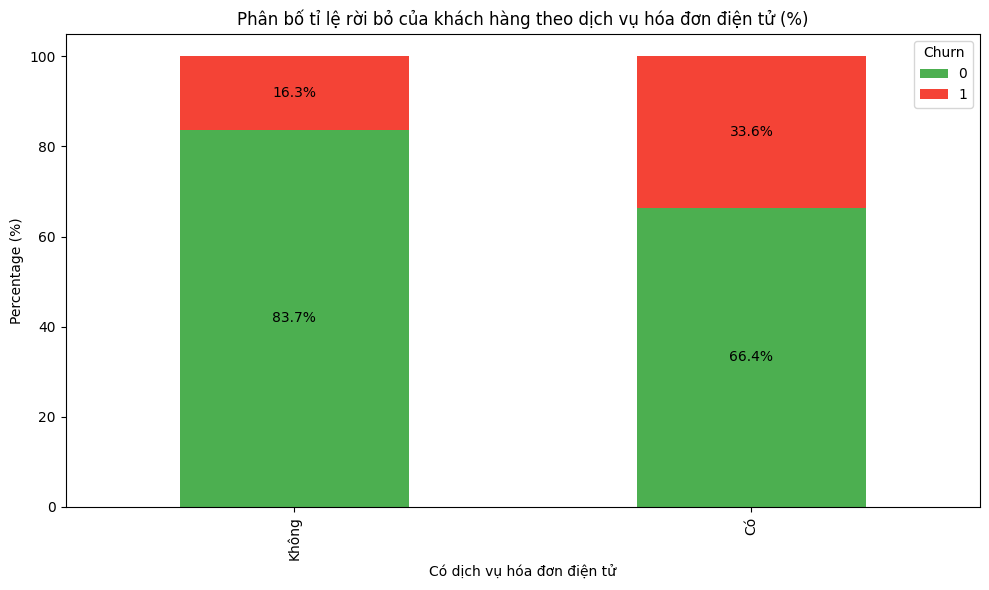

In [132]:
# vẽ biểu đồ phân phối tỉ lệ rời bỏ của khách hàng theo có dịch vụ hóa đơn diện tử (%)
churn_paperless_pct = pd.crosstab(df['PaperlessBilling'], df['Churn'], normalize='index') * 100
ax = churn_paperless_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#4CAF50', '#F44336'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')
plt.title('Phân bố tỉ lệ rời bỏ của khách hàng theo dịch vụ hóa đơn điện tử (%)')
plt.xlabel('Có dịch vụ hóa đơn điện tử')
plt.ylabel('Percentage (%)')
plt.legend(title='Churn')
plt.xticks([0, 1], ['Không', 'Có'] )
plt.tight_layout()
plt.show()

# Xây Dựng Mô Hình Machine Learning

In [133]:
df=pd.read_csv("cleaned_telco.csv")
print(df.shape)

(7043, 21)


In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [135]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [149]:
data = df.copy()

## Xử lý dữ liệu cho mô hình


In [150]:
data['Churn'] = data['Churn'].map({'Yes':1, 'No':0})

In [151]:
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling']

for col in binary_cols:
    data[col] = data[col].map({'Yes':1, 'No':0})

In [152]:
data['gender'] = data['gender'].map({'Male':1, 'Female':0})

In [153]:
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']

for col in service_cols:
    data[col] = data[col].map({'Yes':1, 'No':0})

In [154]:
data['MultipleLines'] = data['MultipleLines'].map({'Yes':1, 'No':0})

In [155]:
data['SeniorCitizen'] = data['SeniorCitizen'].map({'Yes':1, 'No':0})

In [156]:
data['tenure_group'] = pd.cut(
    data['tenure'],
    bins=[0, 6, 12, data['tenure'].max()],
    labels=['0-6', '6-12', '12+'],
    right=False
)

In [157]:
# one-hot encoding cho cột Contract
data = pd.get_dummies(data, columns=['Contract'], drop_first=True)
# one-hot encoding cho cột PaymentMethod
data = pd.get_dummies(data, columns=['PaymentMethod'], drop_first=True)
# one-hot encoding cho cột tenure_group
data = pd.get_dummies(data, columns=['tenure_group'], drop_first=True)
# one-hot encoding cho cột InternetService
data = pd.get_dummies(data, columns=['InternetService'], drop_first=True)
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   gender                                 7043 non-null   int64  
 2   SeniorCitizen                          7043 non-null   int64  
 3   Partner                                7043 non-null   int64  
 4   Dependents                             7043 non-null   int64  
 5   tenure                                 7043 non-null   int64  
 6   PhoneService                           7043 non-null   int64  
 7   MultipleLines                          7043 non-null   int64  
 8   OnlineSecurity                         7043 non-null   int64  
 9   OnlineBackup                           7043 non-null   int64  
 10  DeviceProtection                       7043 non-null   int64  
 11  Tech

In [158]:
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

In [159]:
data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_6-12,tenure_group_12+,InternetService_Fiber optic,InternetService_No
0,7590-VHVEG,0,0,1,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
1,5575-GNVDE,1,0,0,0,34,1,0,1,0,...,0,1,0,0,0,1,0,1,0,0
2,3668-QPYBK,1,0,0,0,2,1,0,1,1,...,1,0,0,0,0,1,0,0,0,0
3,7795-CFOCW,1,0,0,0,45,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
4,9237-HQITU,0,0,0,0,2,1,0,0,0,...,1,0,0,0,1,0,0,0,1,0


In [160]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   gender                                 7043 non-null   int64  
 2   SeniorCitizen                          7043 non-null   int64  
 3   Partner                                7043 non-null   int64  
 4   Dependents                             7043 non-null   int64  
 5   tenure                                 7043 non-null   int64  
 6   PhoneService                           7043 non-null   int64  
 7   MultipleLines                          7043 non-null   int64  
 8   OnlineSecurity                         7043 non-null   int64  
 9   OnlineBackup                           7043 non-null   int64  
 10  DeviceProtection                       7043 non-null   int64  
 11  Tech

In [161]:
# chuẩn bị dữ liệu cho mô hình
from sklearn.model_selection import train_test_split

# X, y
X = data.drop(['Churn', 'customerID'], axis=1)
y = data['Churn']

# Split (8 train, 2 test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [162]:
# scale dữ liệu cho các cột số
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

### Logistic Regression

In [163]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# Predict
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

In [165]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_log))

# Precision, Recall, F1
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

# ROC-AUC (quan trọng nhất)
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

# Full report
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))



Accuracy: 0.8069552874378992
Precision: 0.6666666666666666
Recall: 0.5454545454545454
F1-score: 0.6
ROC-AUC: 0.8460642227905655

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.67      0.55      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### Random Forest

In [166]:
# mô hình Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)

In [167]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [168]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.794180269694819
Precision: 0.6707317073170732
Recall: 0.4411764705882353
F1-score: 0.532258064516129
ROC-AUC: 0.8447118241235888

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.87      1035
           1       0.67      0.44      0.53       374

    accuracy                           0.79      1409
   macro avg       0.75      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



### Mô hình XGboost


In [169]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

c:\Users\vhgam\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:21:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [170]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [171]:
# đánh giá mô hình XGBoost
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1-score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

Accuracy: 0.7998580553584103
Precision: 0.6543624161073825
Recall: 0.5213903743315508
F1-score: 0.5803571428571429
ROC-AUC: 0.8412953060011883

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



### mô hình Neural Network

In [172]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 2 layer
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train)

c:\Users\vhgam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)

In [173]:
y_pred_mlp = mlp_model.predict(X_test_scaled)
y_prob_mlp = mlp_model.predict_proba(X_test_scaled)[:, 1]

In [174]:
# đánh giá mô hình Neural Network
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("Precision:", precision_score(y_test, y_pred_mlp))
print("Recall:", recall_score(y_test, y_pred_mlp))
print("F1-score:", f1_score(y_test, y_pred_mlp))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_mlp))
print("\nClassification Report:\n", classification_report(y_test, y_pred_mlp))

Accuracy: 0.7579843860894251
Precision: 0.5459610027855153
Recall: 0.5240641711229946
F1-score: 0.5347885402455662
ROC-AUC: 0.7940039784029553

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.84      0.84      1035
           1       0.55      0.52      0.53       374

    accuracy                           0.76      1409
   macro avg       0.69      0.68      0.69      1409
weighted avg       0.75      0.76      0.76      1409



### Tối ưu mô hình

In [175]:
# Mô hình logistic regression có thể là lựa chọn tốt nhất vì có độ chính xác cao, F1-score tốt và đặc biệt là ROC-AUC cao, cho thấy khả năng phân biệt giữa khách hàng rời bỏ và không rời bỏ rất tốt. Random Forest và XGBoost cũng có hiệu suất khá tốt, nhưng MLP lại có hiệu suất thấp hơn đáng kể, có thể do dữ liệu không đủ lớn hoặc cần điều chỉnh tham số.
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'class_weight': [None, 'balanced'],
    'solver': ['lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='recall', 
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)

Best params: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}


In [176]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)[:,1]

In [177]:
from sklearn.metrics import classification_report, roc_auc_score
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1-score:", f1_score(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_best))
print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_best))

Accuracy: 0.7444996451383961
Precision: 0.5119453924914675
Recall: 0.8021390374331551
F1-score: 0.625
ROC-AUC: 0.8448629517683226
              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC: 0.8448629517683226


In [185]:
# Lưu mô hình tốt nhất
import joblib   
joblib.dump(best_model, "churn_model.pkl")

['churn_model.pkl']

In [179]:
results = pd.DataFrame({
    'customerID': data.loc[X_test.index, 'customerID'],
    'Churn': data.loc[X_test.index, 'Churn'],
    'Churn_Prediction': y_pred_log,
    'Churn_Probability': y_prob_log
})


In [180]:
results.sample(10)

,customerID,Churn,Churn_Prediction,Churn_Probability
900,1051-GEJLJ,0,0,0.202468
4004,5803-NQJZO,0,0,0.016668
6399,2101-RANCD,0,0,0.358560
4018,2969-WGHQO,0,0,0.116702
2012,6845-RGTYS,1,0,0.364071
342,7520-HQWJU,0,0,0.052647
3812,8573-JGCZW,0,0,0.061048
4782,6175-IRFIT,0,1,0.641078
4721,4211-MMAZN,1,0,0.209717
3524,4706-AXVKM,1,1,0.659537


In [181]:
results['Churn'] = results['Churn'].map({1: 'Yes', 0: 'No'})
results['Churn_Prediction'] = results['Churn_Prediction'].map({1: 'Yes', 0: 'No'})

In [182]:
results.sample(10)

,customerID,Churn,Churn_Prediction,Churn_Probability
2421,3893-JRNFS,No,No,0.136524
2568,2266-FUBDZ,No,No,0.016600
3069,1784-BXEFA,No,No,0.145887
6991,3585-ISXZP,Yes,Yes,0.626948
6230,9962-BFPDU,No,No,0.179092
216,9286-BHDQG,No,No,0.009324
3869,1357-BIJKI,No,No,0.348668
7001,6304-IJFSQ,Yes,No,0.416222
524,8397-MVTAZ,Yes,Yes,0.647906
1420,8785-CJSHH,No,No,0.448904


In [183]:
# Lưu kết quả dự đoán vào file CSV
results.to_csv("churn_predictions.csv", index=False)

In [184]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [187]:
joblib.dump(X_train.columns, 'model_columns.pkl')

['model_columns.pkl']